<a href="https://colab.research.google.com/github/sba25046/ml-test/blob/main/coal_electricity_time_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# US Coal Electricity Generation — Time Series Analysis & Forecasting

**Dataset:** Monthly Net Generation from Coal, US Electric Power Sector  
**Source:** US Energy Information Administration (EIA)  
**Units:** Thousand Megawatthours (MWh)

---

This notebook walks through a full time series analysis:
1. Load and explore the data
2. Plot the raw series
3. Decompose into trend, seasonal, and residual components
4. Comment on key patterns
5. Build a SARIMA forecast for the next 24 months
6. Discuss forecast confidence and model limitations

## 0. Setup — Install & Import Libraries

All libraries below are available in Google Colab by default. We use:
- **pandas / numpy** — data loading and manipulation
- **matplotlib / seaborn** — plotting
- **statsmodels** — decomposition, SARIMA modelling, and diagnostics

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore')  # suppress convergence warnings for cleaner output

# ── Plotting style ──────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9
})

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 1. Load and Explore the Data

We parse the `Date` column (format: `Jan-73`) into a proper datetime index,
then inspect shape, date range, and basic statistics.

In [4]:
# ── Load the CSV ─────────────────────────────────────────────────────────────
# Update this path if running locally; in Colab use the file upload widget.
FILE_PATH = 'Electricity_Net_Generation_From_Coal_Electric_Power_Sector_Monthly.csv'

df = pd.read_csv(FILE_PATH)

# ── Parse dates ──────────────────────────────────────────────────────────────
# The date format is 'Jan-73' — we tell pandas to interpret it as month-year.
df['Date'] = pd.to_datetime(df['Date'], format='%b-%y')

# Fix a common two-digit year ambiguity: pandas maps '73' → 2073 for years
# below 1970. We shift any future dates back by 100 years.
df['Date'] = df['Date'].apply(
    lambda d: d - pd.DateOffset(years=100) if d.year > pd.Timestamp.now().year else d
)

df = df.set_index('Date').sort_index()
df.columns = ['generation_kwh']   # rename for clarity

# Set explicit monthly frequency so statsmodels decomposition works cleanly
df = df.asfreq('MS')  # month-start frequency

# ── Basic exploration ────────────────────────────────────────────────────────
print('=== Shape ===')
print(f'  Rows: {df.shape[0]}  |  Columns: {df.shape[1]}')

print('\n=== Date Range ===')
print(f'  Start : {df.index.min().strftime("%B %Y")}')
print(f'  End   : {df.index.max().strftime("%B %Y")}')
print(f'  Span  : ~{(df.index.max().year - df.index.min().year)} years')

print('\n=== Missing Values ===')
print(f'  {df.isnull().sum().values[0]} missing observations')

print('\n=== Basic Statistics (Thousand MWh) ===')
print(df.describe().round(1).to_string())

=== Shape ===
  Rows: 579  |  Columns: 1

=== Date Range ===
  Start : January 1973
  End   : March 2021
  Span  : ~48 years

=== Missing Values ===
  0 missing observations

=== Basic Statistics (Thousand MWh) ===
       generation_kwh
count           579.0
mean         123397.4
std           33025.3
min           40188.5
25%           95734.9
50%          126953.3
75%          149286.9
max          188516.1


In [5]:
# ── Annual average by decade — a useful quick summary ────────────────────────
df['decade'] = (df.index.year // 10) * 10
decade_summary = df.groupby('decade')['generation_kwh'].agg(['mean','min','max']).round(0)
decade_summary.columns = ['Mean', 'Min', 'Max']
decade_summary.index = [f"{d}s" for d in decade_summary.index]
print('=== Average Monthly Generation by Decade (Thousand MWh) ===')
print(decade_summary.to_string())
df.drop(columns='decade', inplace=True)

=== Average Monthly Generation by Decade (Thousand MWh) ===
           Mean       Min       Max
1970s   77491.0   62866.0   97910.0
1980s  112605.0   83562.0  152377.0
1990s  142150.0  113699.0  181288.0
2000s  160972.0  124803.0  188516.0
2010s  117101.0   59426.0  177778.0
2020s   66566.0   40189.0   90814.0


---
## 2. Plot the Raw Time Series

Before decomposing or modelling anything, we plot the full series to get a
feel for the overall shape — growth phases, turning points, and volatility.

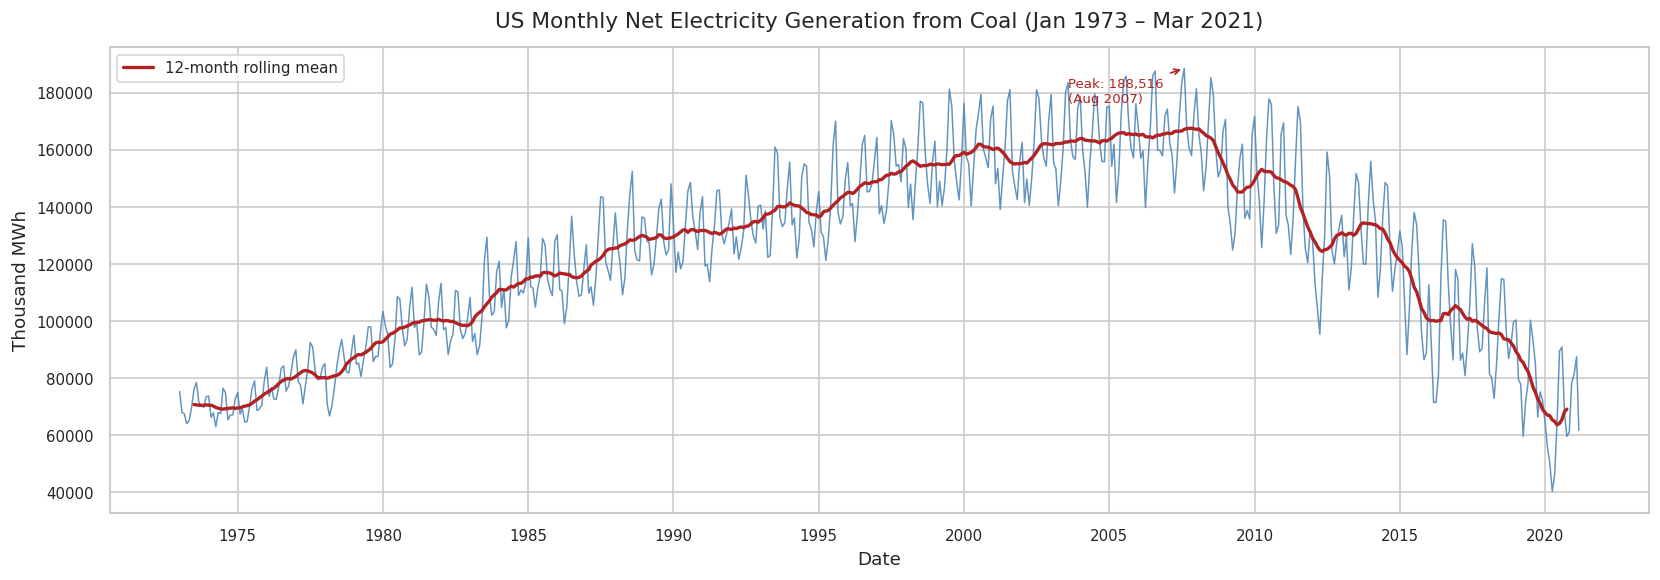

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df['generation_kwh'], color='steelblue', linewidth=0.9, alpha=0.85)

# Annotate the overall peak
peak_idx = df['generation_kwh'].idxmax()
peak_val = df['generation_kwh'].max()
ax.annotate(
    f'Peak: {peak_val:,.0f}\n({peak_idx.strftime("%b %Y")})',
    xy=(peak_idx, peak_val),
    xytext=(peak_idx - pd.DateOffset(years=4), peak_val - 12000),
    arrowprops=dict(arrowstyle='->', color='firebrick'),
    fontsize=8, color='firebrick'
)

# Add a 12-month rolling mean to show the trend more clearly
rolling_mean = df['generation_kwh'].rolling(window=12, center=True).mean()
ax.plot(df.index, rolling_mean, color='firebrick', linewidth=2, label='12-month rolling mean')

ax.set_title('US Monthly Net Electricity Generation from Coal (Jan 1973 – Mar 2021)', pad=12)
ax.set_ylabel('Thousand MWh')
ax.set_xlabel('Date')
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

---
## 3. Decompose the Time Series

We use **classical multiplicative decomposition** (`seasonal_decompose` from
statsmodels). Multiplicative is appropriate here because the seasonal swings
grow and shrink roughly in proportion to the level of the series — a feature
visible even in the raw plot.

The decomposition splits the series into three components:
- **Trend** — the long-run direction, smoothed out
- **Seasonal** — the repeating monthly pattern (period = 12)
- **Residual** — what's left after removing trend and seasonality (irregular shocks)

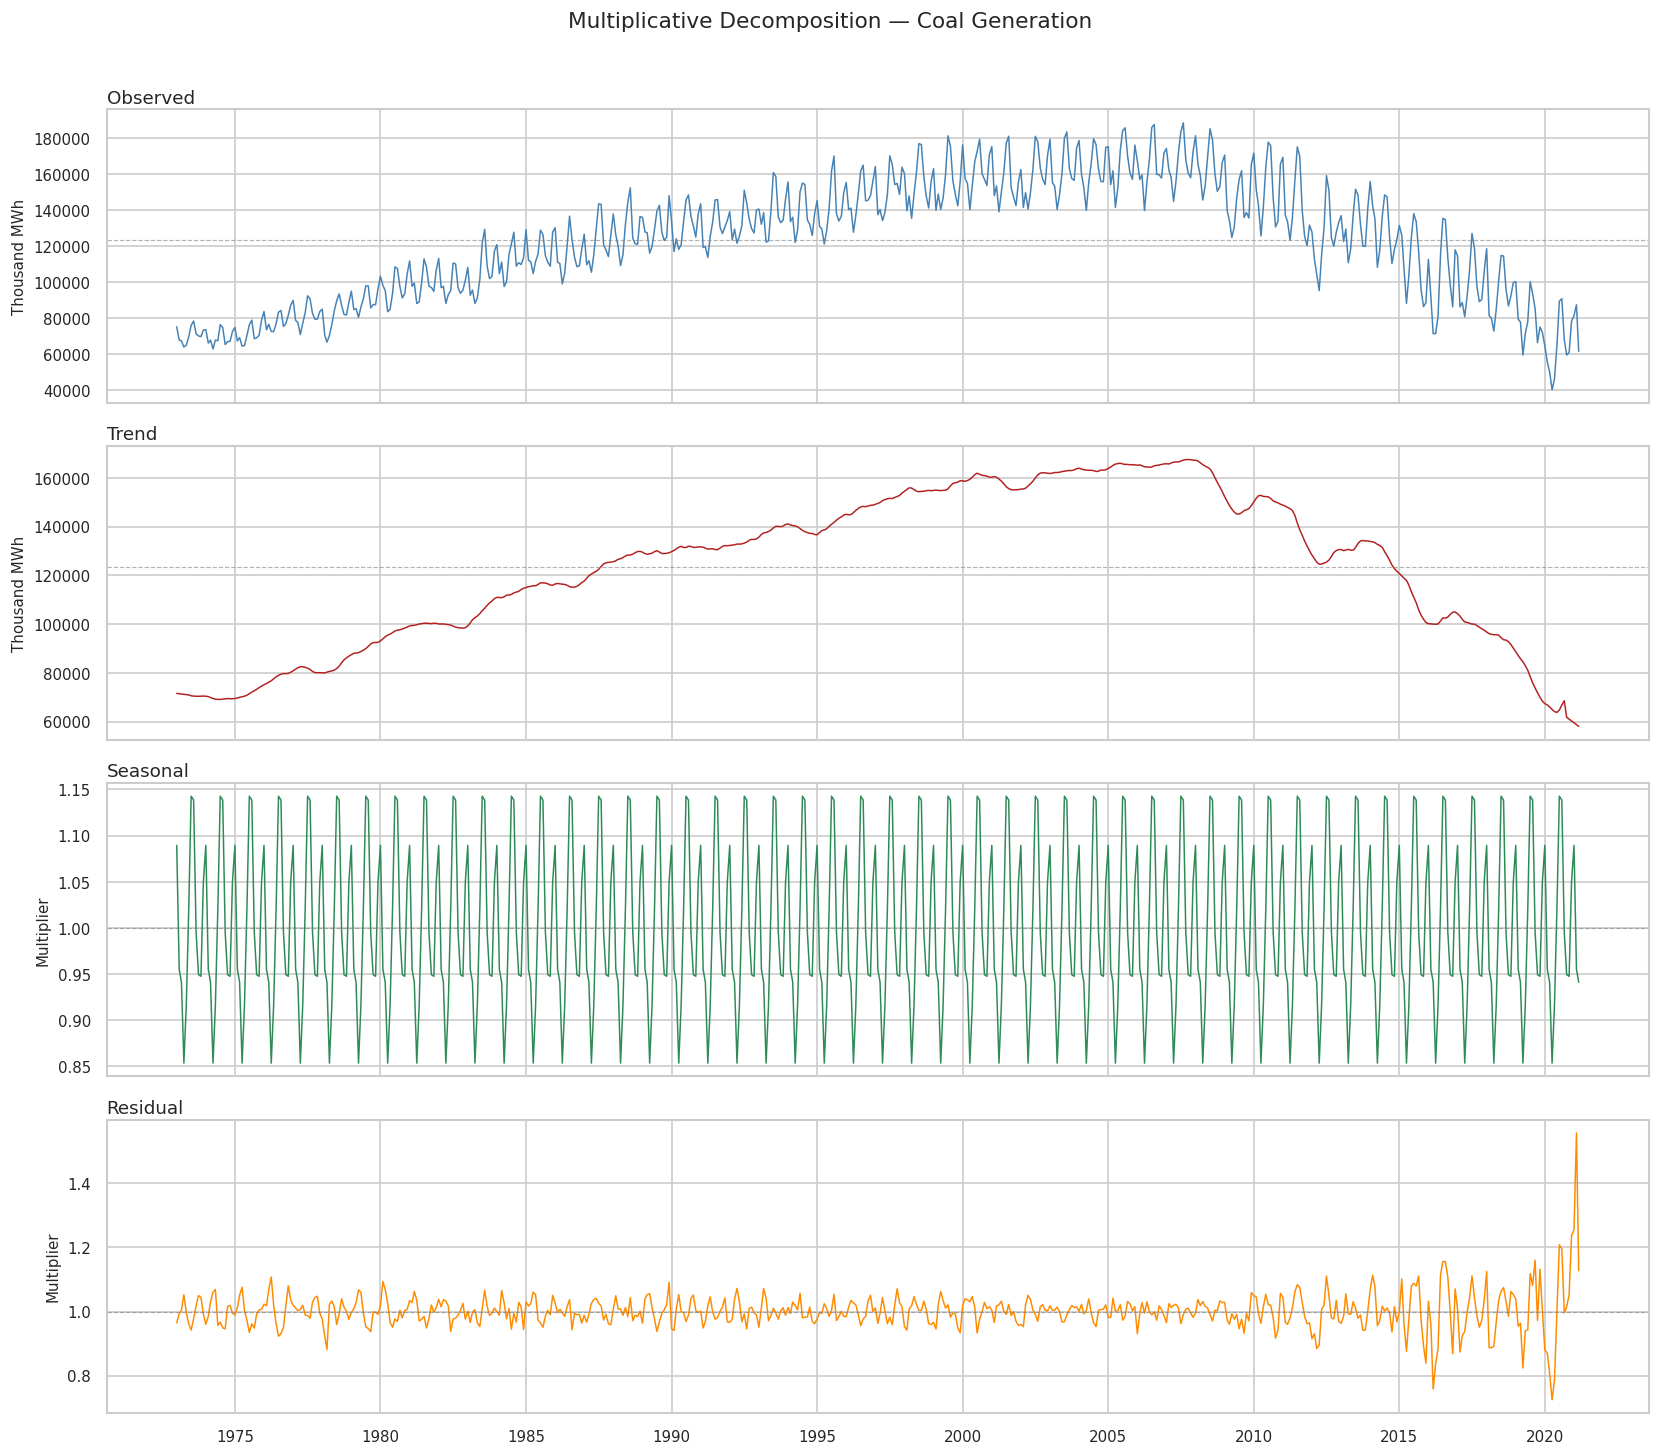

In [7]:
# Multiplicative decomposition with a 12-month (annual) seasonal period
decomp = seasonal_decompose(
    df['generation_kwh'],
    model='multiplicative',
    period=12,
    extrapolate_trend='freq'   # fills the first/last 6-month edge that a moving average leaves NaN
)

# ── Plot all four panels ─────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

panels = [
    (decomp.observed,  'Observed',  'steelblue',   'Thousand MWh'),
    (decomp.trend,     'Trend',     'firebrick',   'Thousand MWh'),
    (decomp.seasonal,  'Seasonal',  'seagreen',    'Multiplier'),
    (decomp.resid,     'Residual',  'darkorange',  'Multiplier'),
]

for ax, (component, title, color, ylabel) in zip(axes, panels):
    ax.plot(df.index, component, color=color, linewidth=0.9)
    ax.axhline(1 if title in ('Seasonal', 'Residual') else component.mean(),
               color='grey', linestyle='--', linewidth=0.7, alpha=0.6)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=11, loc='left', pad=4)

axes[-1].xaxis.set_major_locator(mdates.YearLocator(5))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle('Multiplicative Decomposition — Coal Generation', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

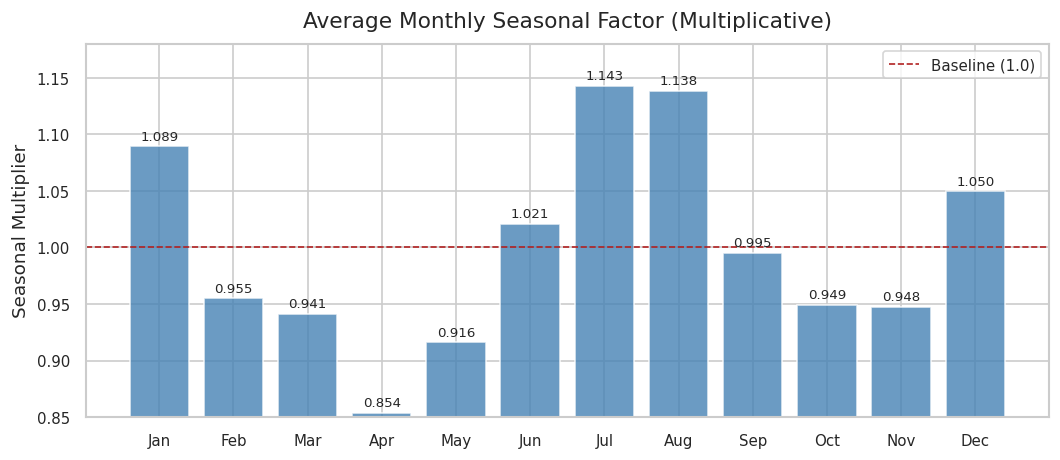


Seasonal factors (values > 1.0 = above average; < 1.0 = below average):
  Jan: 1.0894
  Feb: 0.9552
  Mar: 0.9412
  Apr: 0.8536
  May: 0.9162
  Jun: 1.0211
  Jul: 1.1427
  Aug: 1.1385
  Sep: 0.9953
  Oct: 0.9494
  Nov: 0.9477
  Dec: 1.0495


In [8]:
# ── Monthly seasonal profile (average seasonal factor per calendar month) ────
seasonal_profile = (
    decomp.seasonal
    .groupby(decomp.seasonal.index.month)
    .mean()
)
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(month_names, seasonal_profile.values, color='steelblue', alpha=0.8)
ax.axhline(1.0, color='firebrick', linestyle='--', linewidth=1, label='Baseline (1.0)')

# Label each bar with the multiplier value
for bar, val in zip(bars, seasonal_profile.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_title('Average Monthly Seasonal Factor (Multiplicative)', pad=10)
ax.set_ylabel('Seasonal Multiplier')
ax.set_ylim(0.85, 1.18)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('\nSeasonal factors (values > 1.0 = above average; < 1.0 = below average):')
for m, v in zip(month_names, seasonal_profile.values):
    print(f'  {m}: {v:.4f}')

---
## 4. Key Patterns and Commentary

Based on the plots above, here is what the data shows:

### Long-run trend
Coal generation **rose steadily from 1973 through the mid-2000s**, peaking around
2007–2008 at roughly 180,000–188,000 thousand MWh per month. After that peak,
the trend enters a **sustained, accelerating decline** — driven by the shale gas
revolution (cheap natural gas), rapid growth in renewable capacity, increasingly
strict environmental regulation, and ageing coal plant retirements. By early
2021 (the end of the dataset), monthly generation has fallen back to levels last
seen in the 1970s.

### Seasonal cycle
There is a clear and consistent **annual seasonal pattern**. Generation peaks in
**summer (July–August)** due to air-conditioning load, and again — to a lesser
extent — in **winter (December–January)** for heating. The lowest months are
**spring (April–May)** and **autumn (September–October)**, when demand is
naturally low. This pattern is stable across all decades, though the amplitude
has shrunk somewhat as coal's share of the generation mix has declined.

### Notable shocks
- **2008–2009 financial crisis**: A noticeable drop in the residual component
  as industrial demand collapsed.
- **2012**: A particularly sharp single-year dip — natural gas prices briefly
  fell below coal on a per-MWh basis, causing widespread fuel switching.
- **2020 (COVID-19)**: Visible in the residual as demand dropped abruptly in
  spring 2020 before partially recovering.

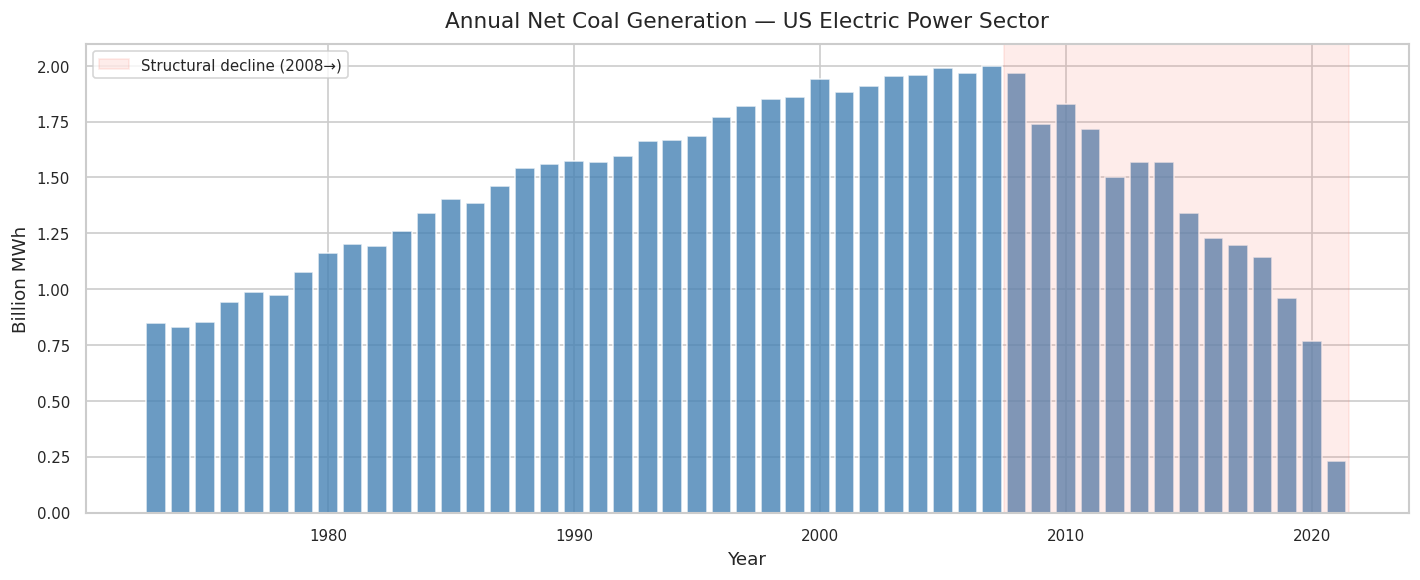

In [9]:
# ── Visualise the trend decline more clearly ─────────────────────────────────
# Annual totals give a cleaner picture than monthly noise
annual = df['generation_kwh'].resample('A').sum() / 1e6  # convert to billion MWh for readability

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(annual.index.year, annual.values, color='steelblue', alpha=0.8, width=0.8)

# Shade the decline period
ax.axvspan(2007.5, annual.index.year[-1] + 0.5, color='salmon', alpha=0.15, label='Structural decline (2008→)')

ax.set_title('Annual Net Coal Generation — US Electric Power Sector', pad=10)
ax.set_ylabel('Billion MWh')
ax.set_xlabel('Year')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 5. Forecasting the Next 24 Months — SARIMA Model

### Why SARIMA?
We have a **univariate** series with a known seasonal period of 12 months and a
strong downward trend. **SARIMA(p,d,q)(P,D,Q)[12]** is a natural fit — it handles
both differencing (to remove trend) and seasonal differencing natively.

### Stationarity check
Before fitting, we verify whether the series needs differencing using the
Augmented Dickey-Fuller (ADF) test. A p-value above 0.05 indicates the series
is non-stationary (has a unit root), meaning `d ≥ 1` is required.

In [10]:
# ── Augmented Dickey-Fuller test on the raw series ───────────────────────────
adf_result = adfuller(df['generation_kwh'].dropna(), autolag='AIC')

print('=== ADF Test — Raw Series ===')
print(f'  Test statistic : {adf_result[0]:.4f}')
print(f'  p-value        : {adf_result[1]:.4f}')
print(f'  Lags used      : {adf_result[2]}')
print(f'  Interpretation : {"Stationary (reject H0)" if adf_result[1] < 0.05 else "Non-stationary (fail to reject H0) — differencing needed"}')

# ── ADF on first-differenced series ─────────────────────────────────────────
diff1 = df['generation_kwh'].diff().dropna()
adf_diff = adfuller(diff1, autolag='AIC')
print('\n=== ADF Test — First Differenced Series ===')
print(f'  Test statistic : {adf_diff[0]:.4f}')
print(f'  p-value        : {adf_diff[1]:.4f}')
print(f'  Interpretation : {"Stationary — d=1 is sufficient" if adf_diff[1] < 0.05 else "Still non-stationary"}')

=== ADF Test — Raw Series ===
  Test statistic : -1.1429
  p-value        : 0.6977
  Lags used      : 18
  Interpretation : Non-stationary (fail to reject H0) — differencing needed

=== ADF Test — First Differenced Series ===
  Test statistic : -6.0823
  p-value        : 0.0000
  Interpretation : Stationary — d=1 is sufficient


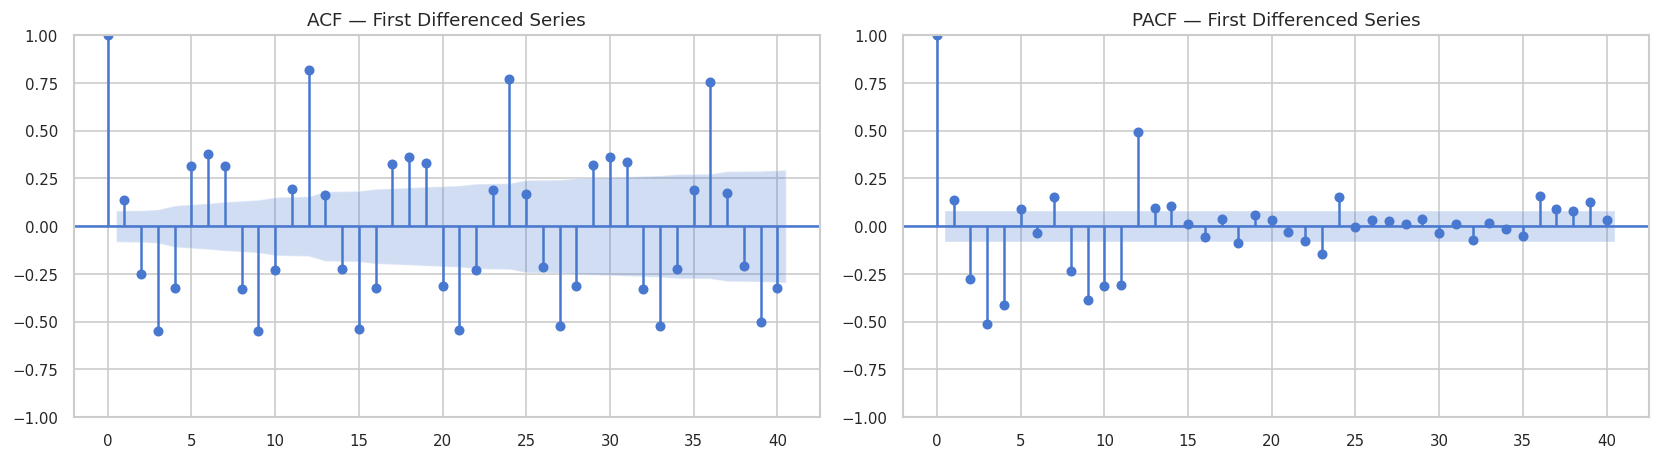

In [11]:
# ── ACF / PACF plots on first-differenced series ─────────────────────────────
# These help identify the AR (p) and MA (q) orders
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(diff1, lags=40, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF — First Differenced Series', fontsize=11)

plot_pacf(diff1, lags=40, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('PACF — First Differenced Series', fontsize=11)

plt.tight_layout()
plt.show()

In [12]:
# ── Fit SARIMA model ──────────────────────────────────────────────────────────
# Order choice:
#   (p=1, d=1, q=1)  — standard first-order ARIMA for the non-seasonal component
#   (P=1, D=1, Q=1)[12] — seasonal ARIMA at 12-month period
# This is a commonly well-performing default; for production use, grid-search AIC.

ORDER        = (1, 1, 1)   # (p, d, q)
SEASONAL_ORDER = (1, 1, 1, 12)  # (P, D, Q, m)

model = SARIMAX(
    df['generation_kwh'],
    order=ORDER,
    seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False
)

print('Fitting SARIMA(1,1,1)(1,1,1)[12] — this may take a few seconds...')
fitted_model = model.fit(disp=False)
print(fitted_model.summary())

Fitting SARIMA(1,1,1)(1,1,1)[12] — this may take a few seconds...
                                     SARIMAX Results                                      
Dep. Variable:                     generation_kwh   No. Observations:                  579
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -5570.689
Date:                            Fri, 03 Apr 2026   AIC                          11151.377
Time:                                    19:13:49   BIC                          11172.945
Sample:                                01-01-1973   HQIC                         11159.804
                                     - 03-01-2021                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6605      0.043     15.307     

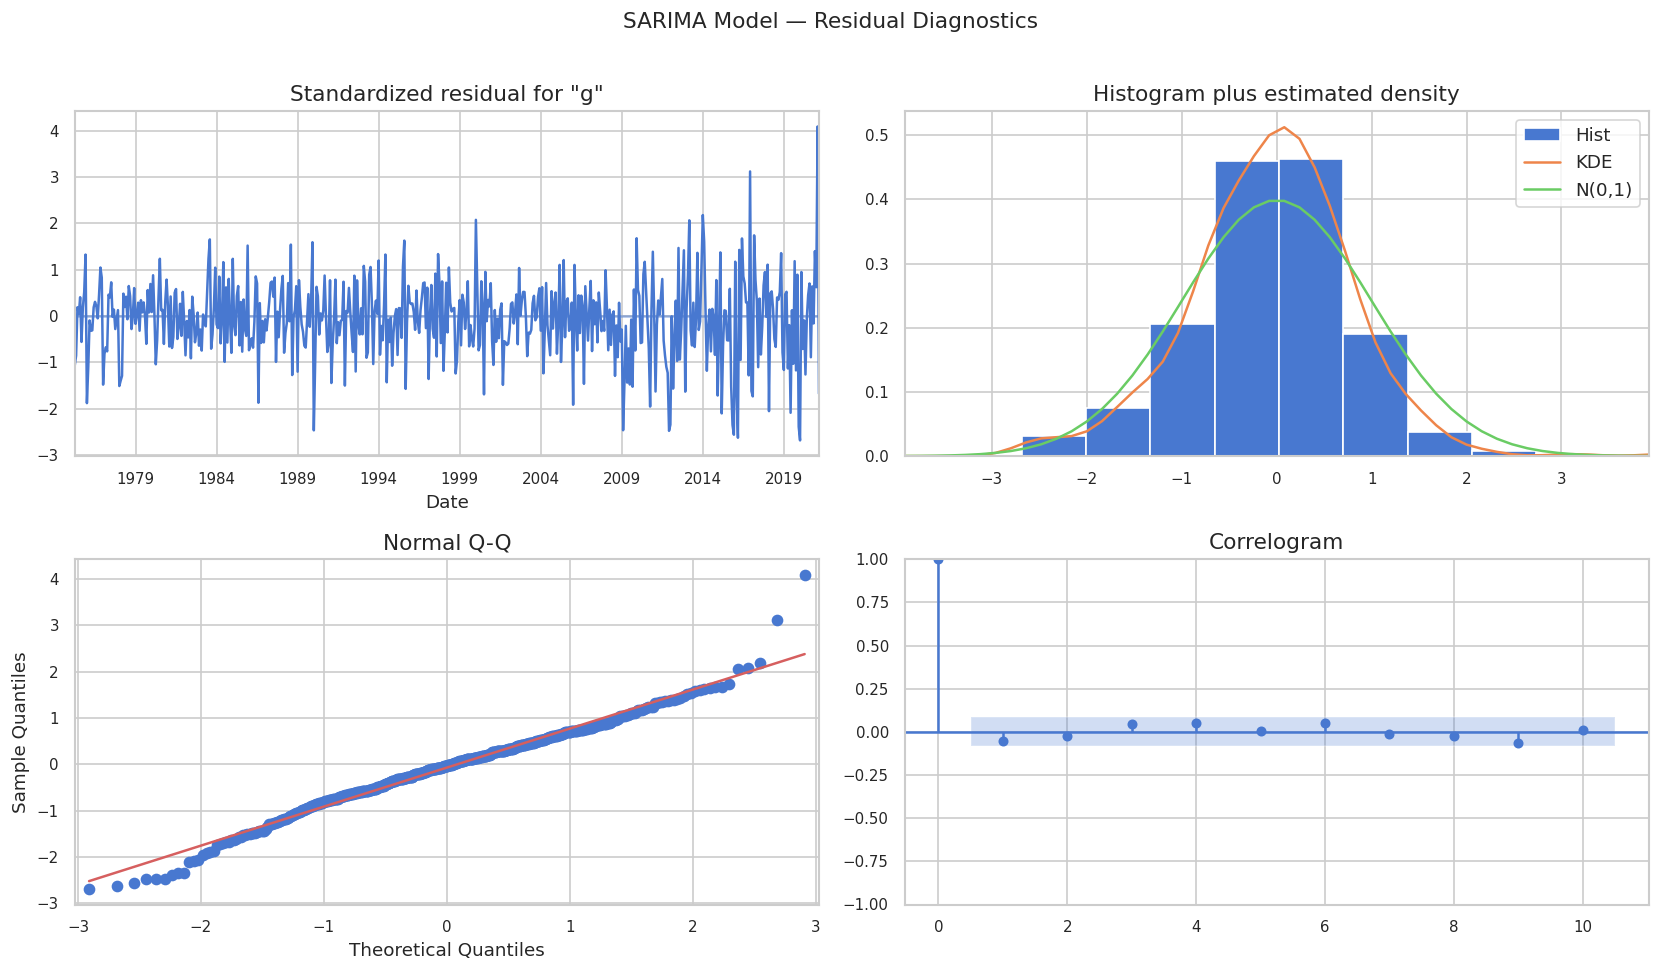

In [13]:
# ── Residual diagnostics ──────────────────────────────────────────────────────
# Good residuals should look like white noise:
# normally distributed, zero mean, no autocorrelation
fig = fitted_model.plot_diagnostics(figsize=(14, 8))
fig.suptitle('SARIMA Model — Residual Diagnostics', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

In [14]:
# ── Generate 24-month forecast ────────────────────────────────────────────────
FORECAST_STEPS = 24

forecast_obj = fitted_model.get_forecast(steps=FORECAST_STEPS)
forecast_mean = forecast_obj.predicted_mean
conf_int      = forecast_obj.conf_int(alpha=0.05)  # 95% confidence intervals

# ── Build a tidy forecast DataFrame ─────────────────────────────────────────
forecast_index = pd.date_range(
    start=df.index[-1] + pd.DateOffset(months=1),
    periods=FORECAST_STEPS,
    freq='MS'
)
forecast_df = pd.DataFrame({
    'forecast':   forecast_mean.values,
    'lower_95':   conf_int.iloc[:, 0].values,
    'upper_95':   conf_int.iloc[:, 1].values,
}, index=forecast_index)

# Clip lower bound at zero — generation cannot be negative
forecast_df['lower_95'] = forecast_df['lower_95'].clip(lower=0)

print('=== Forecast Summary (Thousand MWh) ===')
print(forecast_df.round(0).to_string())

=== Forecast Summary (Thousand MWh) ===
            forecast  lower_95  upper_95
2021-04-01   46641.0   33443.0   59838.0
2021-05-01   54207.0   37978.0   70436.0
2021-06-01   69582.0   51920.0   87243.0
2021-07-01   89062.0   70614.0  107510.0
2021-08-01   86277.0   67346.0  105208.0
2021-09-01   66963.0   47705.0   86221.0
2021-10-01   54782.0   35282.0   74282.0
2021-11-01   56718.0   37025.0   76410.0
2021-12-01   68312.0   48456.0   88169.0
2022-01-01   70833.0   50831.0   90835.0
2022-02-01   60313.0   40176.0   80449.0
2022-03-01   48190.0   27927.0   68452.0
2022-04-01   35274.0   13893.0   56655.0
2022-05-01   44421.0   22347.0   66496.0
2022-06-01   60603.0   38053.0   83154.0
2022-07-01   80477.0   57570.0  103384.0
2022-08-01   77902.0   54708.0  101097.0
2022-09-01   59056.0   35616.0   82497.0
2022-10-01   46873.0   23213.0   70534.0
2022-11-01   48958.0   25094.0   72822.0
2022-12-01   60336.0   36280.0   84392.0
2023-01-01   62880.0   38639.0   87120.0
2023-02-01   5153

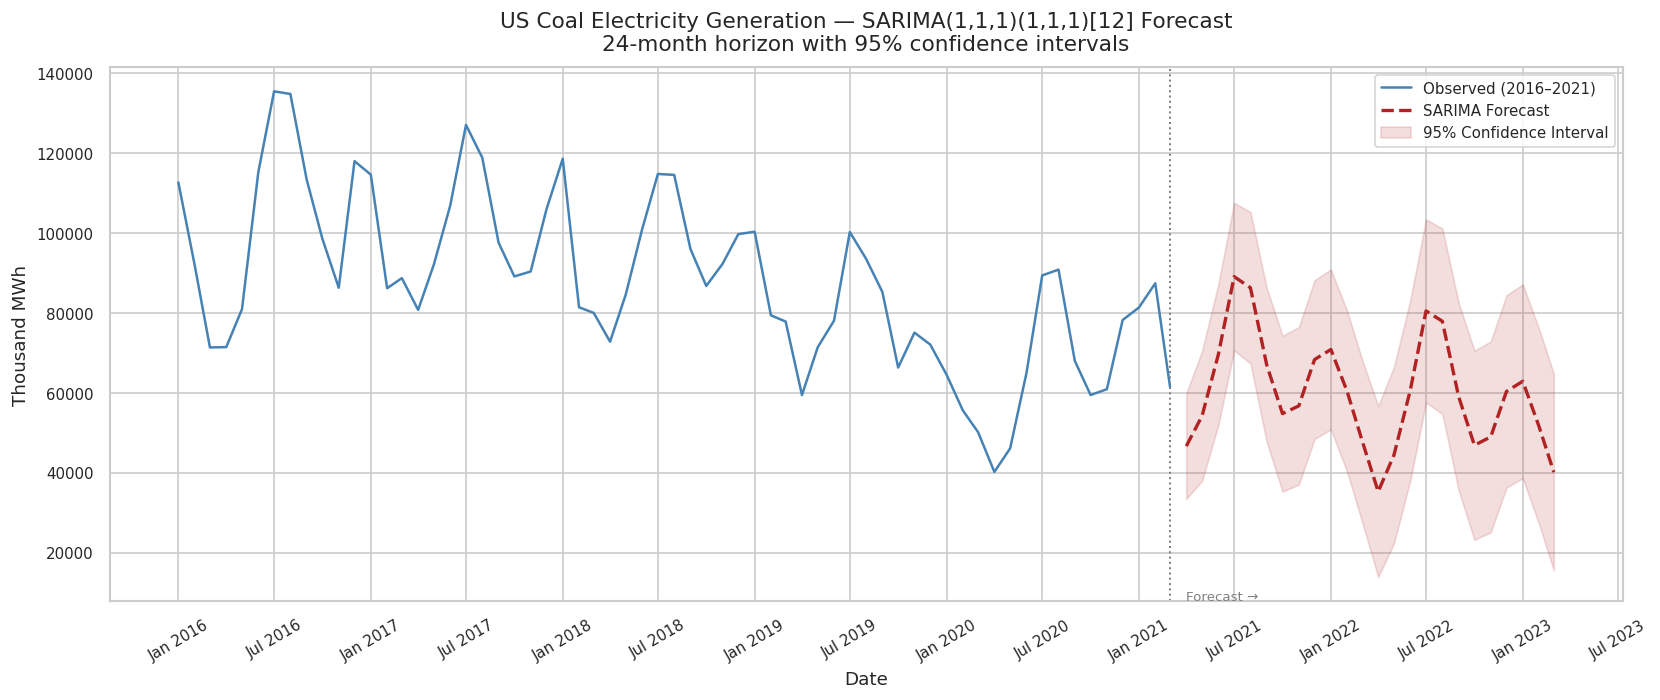

In [15]:
# ── Plot forecast alongside recent history ────────────────────────────────────
# Show only the last 5 years of history for clarity
history_window = df['generation_kwh']['2016':]

fig, ax = plt.subplots(figsize=(14, 6))

# Historical data
ax.plot(
    history_window.index, history_window.values,
    color='steelblue', linewidth=1.5, label='Observed (2016–2021)'
)

# Forecast line
ax.plot(
    forecast_df.index, forecast_df['forecast'],
    color='firebrick', linewidth=2, linestyle='--', label='SARIMA Forecast'
)

# 95% confidence interval shading
ax.fill_between(
    forecast_df.index,
    forecast_df['lower_95'],
    forecast_df['upper_95'],
    color='firebrick', alpha=0.15, label='95% Confidence Interval'
)

# Vertical line marking the forecast start
ax.axvline(df.index[-1], color='grey', linestyle=':', linewidth=1.2)
ax.text(df.index[-1] + pd.DateOffset(months=1),
        ax.get_ylim()[0] * 1.02, 'Forecast →',
        fontsize=8, color='grey')

ax.set_title(
    'US Coal Electricity Generation — SARIMA(1,1,1)(1,1,1)[12] Forecast\n'
    '24-month horizon with 95% confidence intervals',
    pad=10
)
ax.set_ylabel('Thousand MWh')
ax.set_xlabel('Date')
ax.legend(loc='upper right', fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

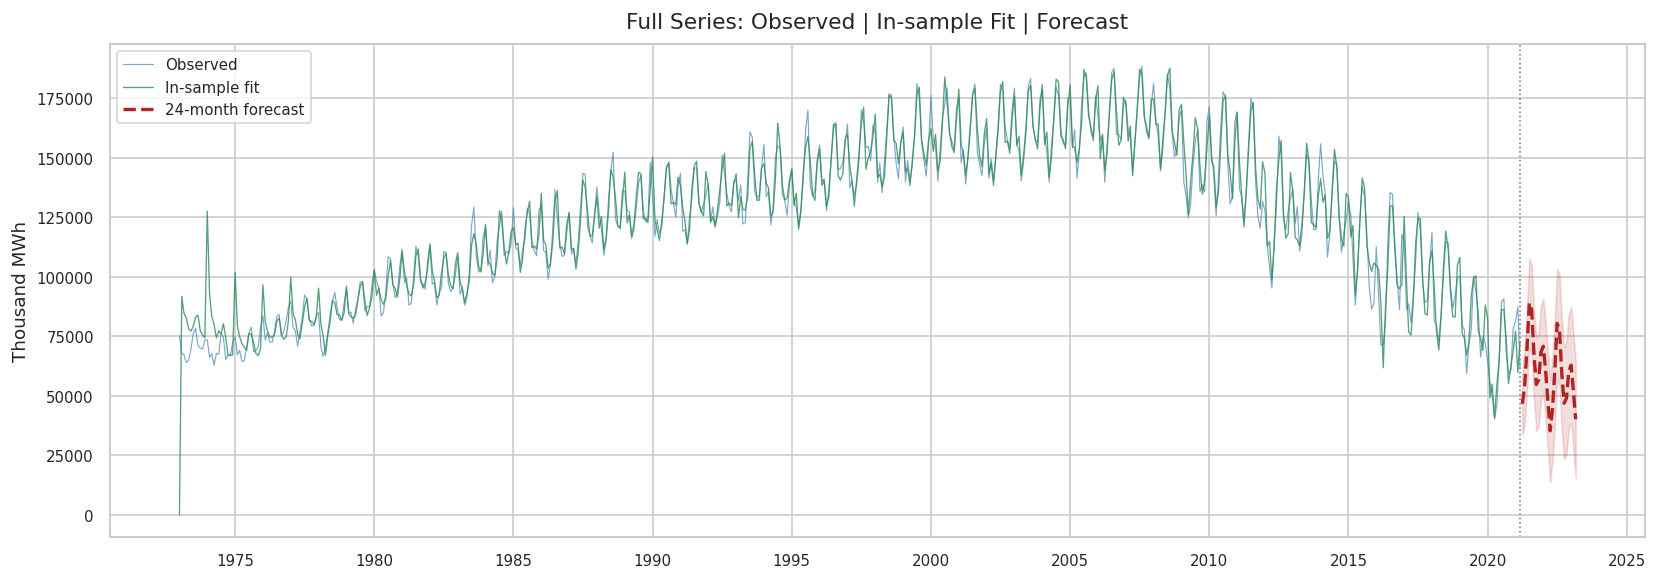

In [16]:
# ── Full history view with in-sample fit + forecast ───────────────────────────
in_sample = fitted_model.fittedvalues

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df['generation_kwh'],
        color='steelblue', linewidth=0.7, alpha=0.7, label='Observed')
ax.plot(in_sample.index, in_sample.values,
        color='seagreen', linewidth=0.8, alpha=0.8, label='In-sample fit')
ax.plot(forecast_df.index, forecast_df['forecast'],
        color='firebrick', linewidth=2, linestyle='--', label='24-month forecast')
ax.fill_between(forecast_df.index,
                forecast_df['lower_95'], forecast_df['upper_95'],
                color='firebrick', alpha=0.15)

ax.axvline(df.index[-1], color='grey', linestyle=':', linewidth=1)
ax.set_title('Full Series: Observed | In-sample Fit | Forecast', pad=10)
ax.set_ylabel('Thousand MWh')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

---
## 6. How Confident Should We Be? — Limitations

### What the model captures well
- The **seasonal pattern** is well-established and stable over decades. The
  summer peak and spring trough are almost certain to continue, so the seasonal
  shape of the forecast is reliable.
- The model correctly captures the **downward momentum** visible in the most
  recent years of data.

### Where confidence is lower

| Limitation | Implication |
|---|---|
| **Trend is structural, not statistical** | Coal's decline is driven by policy, economics, and technology — not just past values. A SARIMA model extrapolates the recent slope; it cannot predict a policy reversal or a technology shock. |
| **Widening confidence intervals** | By design, SARIMA uncertainty compounds over time. The 95% CI is quite wide by month 24 — the actual range of plausible outcomes is large. |
| **No exogenous variables** | Gas prices, renewable capacity additions, carbon pricing, and demand shocks are not in the model. These are the actual drivers of coal dispatch. |
| **Non-linearity risk** | If coal retirements accelerate or a major policy shift occurs, the series could fall faster than the linear extrapolation assumes. |
| **Short recent window** | The model is trained on the full 1973–2021 history. The pre-peak growth phase (1973–2008) still has statistical weight. A model trained only on 2010–2021 would produce a steeper decline forecast. |

### Bottom line
Use this forecast for a **reasonable central estimate** of what continued
decline would look like under similar conditions. Treat the 95% confidence
interval as a statistical floor/ceiling, not a true probability bound on all
possible outcomes. For energy planning purposes, a scenario-based approach
(with explicit assumptions about gas prices, retirements, and policy) would
complement this statistical forecast usefully.

In [17]:
# ── Final summary printout ────────────────────────────────────────────────────
print('=== ANALYSIS SUMMARY ===')
print(f'Dataset       : {df.index.min().strftime("%b %Y")} — {df.index.max().strftime("%b %Y")} ({len(df)} months)')
print(f'Overall mean  : {df["generation_kwh"].mean():,.0f} thousand MWh/month')
print(f'Peak month    : {df["generation_kwh"].idxmax().strftime("%b %Y")} ({df["generation_kwh"].max():,.0f})')
print(f'Latest month  : {df.index[-1].strftime("%b %Y")} ({df["generation_kwh"].iloc[-1]:,.0f})')
print(f'\nForecast model: SARIMA{ORDER}{SEASONAL_ORDER}')
print(f'Horizon       : {FORECAST_STEPS} months')
print(f'\nForecasted month 12 : {forecast_df["forecast"].iloc[11]:,.0f} thousand MWh (95% CI: {forecast_df["lower_95"].iloc[11]:,.0f} – {forecast_df["upper_95"].iloc[11]:,.0f})')
print(f'Forecasted month 24 : {forecast_df["forecast"].iloc[23]:,.0f} thousand MWh (95% CI: {forecast_df["lower_95"].iloc[23]:,.0f} – {forecast_df["upper_95"].iloc[23]:,.0f})')

=== ANALYSIS SUMMARY ===
Dataset       : Jan 1973 — Mar 2021 (579 months)
Overall mean  : 123,397 thousand MWh/month
Peak month    : Aug 2007 (188,516)
Latest month  : Mar 2021 (61,561)

Forecast model: SARIMA(1, 1, 1)(1, 1, 1, 12)
Horizon       : 24 months

Forecasted month 12 : 48,190 thousand MWh (95% CI: 27,927 – 68,452)
Forecasted month 24 : 40,147 thousand MWh (95% CI: 15,551 – 64,742)
